# Site optimisation Example
This is an example of defining the elements that make up a behind the meter site and optimising the charging/discharging of controllable elements. These can include, battery, pv, load, and evs.

# Defining some parameters for the site and optimisation

In [1]:
time_periods = 96                       # the number of intervals that we wish to optimise the site over
interval_duration = 15                  # the duration of each interval (minutes)



# Defining tariffs

Tariff types:
- import_tariff: A straight per kwh cost applied at every time. Defined as an array. Set to None, if not wanted.
- export_tariff: A straight per kwh amount paid at every time. Defined as an array. Set to None if not wanted.
- demand_tariff_list: A list of demand tariffs. The demand tariff is made up of a rate and a window. The window is a binary array/list of when the rate applies. Set to None if not wanted

In [2]:
import sys
sys.path.append("../") # go to parent dir

import numpy as np
from objectives import DemandCharge
# from objectives import DemandCharge

import_tariff_array = np.array(([0.1] * 28 + [0.3] * 8 + [0.2] * 32 + [0.3] * 16 + [0.1] * 12))
export_tariff_array = np.array(([0.1] * 96))

# peak usage
peak_rate = 2.0
peak_window = [0]*28 + [1]*8 + [0]*32 + [1]*12 + [0]*16

peak_charge = DemandCharge(rate=peak_rate, window_array=peak_window, min_demand=0.0)

# shoulder usage
shoulder_rate = 1.0
shoulder_window = [0]*36 + [1]*32 + [0]*12 + [1]*8 + [0]*8

shoulder_charge = DemandCharge(rate=shoulder_rate, window_array=shoulder_window, min_demand=0.0)
demand_tariff_list = [peak_charge, shoulder_charge]

# Define a load profile and pv profile for the site
These are defined as arrays of length time_periods. If there is no pv at the site then set pv_profile=None. PV profile values should be negative as negative is exports. Values are in kW.

In [3]:
load_profile = np.array(
    [2.13, 2.09, 2.3, 2.11, 2.2, 2.23, 2.2, 2.15, 2.02, 2.19, 2.19, 2.19, 2.12, 2.15, 2.25, 2.12, 2.21, 2.16,
     2.26, 2.13, 2.08, 2.15, 2.42, 2.02, 2.3, 2.26, 2.35, 2.55, 3.23, 2.98, 3.49, 3.5, 3.12, 3.52, 3.94, 3.55,
     3.99, 3.71, 3.38, 3.76, 3.71, 3.78, 3.29, 3.65, 3.61, 3.75, 3.38, 3.66, 3.56, 3.69, 3.3, 3.61, 3.71, 3.82,
     3.17, 3.69, 3.74, 3.86, 3.57, 3.55, 3.75, 3.6, 3.67, 3.48, 3.51, 3.46, 3.19, 3.38, 3.19, 3.38, 3.04, 3.12,
     2.91, 3.11, 3.13, 2.77, 2.24, 2.54, 2.24, 2.24, 2.09, 2.33, 2.17, 2.16, 1.97, 2.16, 2.21, 2.18, 2.01, 2.16,
     2.19, 2.11, 2.17, 2.13, 2.05, 2.19])

pv_profile = -1*np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.23, 0.52,
     0.74, 0.71, 0.63, 0.68, 0.97, 0.01, 0.52, 0.83, 0.83, 0.79, 1.22, 1.36, 1.27, 1.42, 1.97, 2.56, 2.91, 3.24,
     3.8, 4.3, 4.62, 4.84, 4.6, 4.17, 3.77, 3.76, 3.38, 2.64, 1.96, 1.76, 1.85, 2.4, 3.82, 5.13, 4.97, 5.02, 5.43,
     5.32, 3.56, 1.75, 1.43, 1.65, 1.69, 2.3, 2.71, 2.41, 2.63, 2.6, 1.9, 0.78, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# if no pv then do pv_profile=None

# Battery definition
Each site can have either 1 battery or no battery. The battery is defined as a dictionary with the following fields:
- max_capacity: maximum capacity of the battery in (kWh)
- depth_of_discharge_limit: percentage minimum charge allowed (0-100)
- charging_power_limit: max charging power (kW)
- dicharging_power_limit: maximum rate of discharge back to the grid (kW)
- charging_efficiency: efficiency of charging (0-1.)
- discharging_efficiency: efficiency of discharging (0-1.)
- initial_state_of_charge: initial charge (kWh)

If there is no battery then set battery=None

In [4]:
battery = {'max_capacity': 15., 'depth_of_discharge_limit':0,
            'charging_power_limit':1.25, 'discharging_power_limit':-1.25,
           'charging_efficiency':1., 'discharging_efficiency':1.,
           'initial_state_of_charge':0}

# Define EVs at the site
EVs at a site are given by a list of dictionaries. Each dictionary defines a single EV. If there are no EVs at a site then set evs=None or evs=[]. The dictionary for each EV has teh following fields:
- name: name of the ev (each ev at a site should have a unique name, important for how results are appended)
- available: a bool array of length time_steps with true when the EV is at the site and available to charge
- usage: an array containing the energy used (kWh) during each interval when the EV is away on a trip (i.e. not available)
- max_capacity: maximum capacity of the EV battery (kWh)
- depth_of_discharge_limit: percentage minimum charge allowed (0-100)
- charging_power_limit: max charging power from the grid  (kW)
- dicharging_power_limit: maximum rate of discharge back to the grid (kW)
- charging_efficiency: efficiency of charging (0-1.)
- discharging_efficiency: efficiency of discharging (0-1.)
- initial_state_of_charge: initial charge (kWh)
- charge_mode: (optional, default=V2G) choose between V0G, V1G, V2G. If V1G then the discharge power limit should be 0
- tod_charging: (optional parameter for V0G charge_mode), this implements a time of day charging protacol. It is a bool array of length time_steps with True at times the ev is permitted to charge.
- soc_conserv: (optional parameter for V1G/V2G) state of charge that a conservative user would like the battery to be above while plugged in (kWh).
- soc_conserv_cost: (optional parameter needed if conserv_soc is used) perceived cost (dolalrs per kwh) for going below the conservative soc limit (not this is not an actual cost incurred by user).


# Define a V2G EV

In [5]:
available1 = np.array([1] * 24 + [0] * 24 + [1] * 24 + [0] * 24)        # binary for when its available to charge
usage1 = np.array([0.0] * 24 + [0.5] * 24 + [0.0] * 24 + [1.0] * 24)    # energy usage on trip at each time period
# first vehicle is V2G
ev1 = {'name':'ev1','available': available1, 'usage': usage1, 'max_capacity': 40., 'depth_of_discharge_limit':0,
       'charging_power_limit':10., 'discharging_power_limit':-10, 'charging_efficiency':1,
       'discharging_efficiency':1,'initial_state_of_charge':20.0, 'charge_mode':'V2G',
       'soc_conserv':20, 'soc_conserv_cost':10}


# Define a V1G EV

In [6]:
# Create vehicle 2
available2 = np.array([1] * 10 + [0] * 10 + [1] * 28 + [0] * 48)
usage2 = np.array([0.0] * 10 + [0.4] * 10 + [0.0] * 28 + [0.5] * 48)

# second vehicle is V1G
ev2 = {'name':'ev2','available': available2, 'usage': usage2, 'max_capacity': 40., 'depth_of_discharge_limit':0,
       'charging_power_limit':10., 'discharging_power_limit':-0., 'charging_efficiency':1,
       'discharging_efficiency':1, 'initial_state_of_charge':0.0, 'charge_mode':'V1G'}

# Define a V0G convenienced charged EV

In [16]:
ev3 = {'name':'ev3','available': available1, 'usage': 20*usage1, 'max_capacity': 40., 'depth_of_discharge_limit':0,
       'charging_power_limit':10., 'discharging_power_limit':-10, 'charging_efficiency':1,
       'discharging_efficiency':1, 'initial_state_of_charge':0.0, 'charge_mode': 'V0G'}

In [17]:
tod_charging = np.ones(available2.shape)
tod_charging[20:30] = 0.            # we dont want to charge in the 20-30 time intervals
ev4 = {'name':'ev4','available': available2, 'usage': usage2, 'max_capacity': 40., 'depth_of_discharge_limit':0,
       'charging_power_limit':10., 'discharging_power_limit':-10, 'charging_efficiency':1,
       'discharging_efficiency':1, 'initial_state_of_charge':0.0, 'charge_mode': 'V0G', 'tod_charging':tod_charging}

# Put the evs together into a list

In [18]:
evs = [ev1, ev2, ev3, ev4]
# if no evs at site then do
# evs=None

# Define the site
Now that we have created all the elements we can define the site. The site is defined as a dictionary with the following elements:
- name: name of the site
- load_profile: the load profile defined before
- pv_profile: pv profile defined earlier, if no pv then set pv_profile=None
- battery: battery dictionary or None as defined earlier
- evs: list of ev dictionaries or None
- export_tariff: the array of price paid for exported energy, needs length time_steps
- import_tariff: the array of cost for importing energy, needs length time_steps
- site_max_import: (optional) constraint on the maximum import from the grid to the site, either a single value or an array of length time_steps
- site_max_export: (optional) constraint on the maximum export the grid to the site, either a single value or an array of length time_steps

Note, if the export and import constraints cause the problem to be infeasible then these constraints will be relaxed while trying to ensure that the violation is as small as possible.

In [19]:
site_max_import_array = 23*np.ones(load_profile.shape)
# site_max_import_array = None

site_dict = {'name':'test_site', 'load_profile':load_profile,
                    'pv_profile':pv_profile, 'battery':battery,
                    'evs':evs, 'export_tariff':export_tariff_array,
                     'import_tariff':import_tariff_array,
                    'site_max_import':site_max_import_array, 'site_max_export':-20,
                    'demand_tariff_list':demand_tariff_list}

# Process the site
This does the following:
- checks that all evs have unique names (important for how results are sorted)
- convenience or time of day charging for any V0G evs
- optimises any V1G/V2G EVs and the battery if present
- aggregates the results and updates the dictionary

Work in progress:
- continued testing
- post run analysis outputs (e.g. V2G available power for grid services)

In [20]:
import os
os.environ['OPTIMISER_ENGINE_EXECUTABLE']='/opt/ibm/ILOG/CPLEX_Studio201/cplex/bin/x86-64_linux/cplex'

from echo_scenario import process_site
site_dict = process_site(site_dict, interval_duration, time_periods)

# Investigate some of the results
We can check the status of the optimisation of battery, V1G, and/or V2G output by Pyomo. This is yet to be fleshed out

In [21]:
print('Pyomo optimisation status is:')
print(site_dict['opt_status'])

Pyomo optimisation status is:

Status: ok
User time: 0.09
Termination condition: optimal
Termination message: MIP - Integer optimal solution\x3a Objective = 2.0000004158e+09
Statistics: 
  Branch and bound: 
    Number of bounded subproblems: 0
    Number of created subproblems: 0
Error rc: 0
Time: 0.15582752227783203



# Checking the site export and import constraints

In [22]:
## Check for any import export constraint violation
export_violation = site_dict['export_violation']
import_violation = site_dict['import_violation']

print('Import constraint violation was {} kW'.format(import_violation))
print('Export constraint violation was {} kW \n'.format(export_violation))

Import constraint violation was -0.0 kW
Export constraint violation was -0.0 kW 



# EV charging status
Look at the individual charging status of each EV, we can see what the charging method was and whether it was succesful or not. If it was infeasible then it outputs the SOC by which a trip couldn't be met (kWh).

In [23]:
from echo_scenario import retrieve_value

for i in range(4):
    print('EV ' + site_dict['evs'][i]['name']+':')
    if retrieve_value(site_dict['evs'][i], 'charge_mode') == 'V0G':
        str = ' with time of day' if retrieve_value(site_dict['evs'][i], 'tod_charging') is not None else ' with convenience'
    else:
        str = ''
    print('\t Specified charging method was '+ retrieve_value(site_dict['evs'][i], 'charge_mode') + str)
    print('\t Charging status was: ' + retrieve_value(site_dict['evs'][i], 'charge_status'))
    print('\t Infeasibility in trips was {} kWh'.format(site_dict['evs'][i]['trip_infeasibility']))
    print('\n')

EV ev1:
	 Specified charging method was V2G
	 Charging status was: success
	 Infeasibility in trips was [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] kWh


EV ev2:
	 Specified charging method was V1G
	 Charging status was: infeasible
	 Infeasibility in trips was [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   8.75 0.
 2.5  1.25 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 3.75 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   1.25 2.5  0.  ] kWh


EV ev3:


# Extract time series power and state of charge results and plot

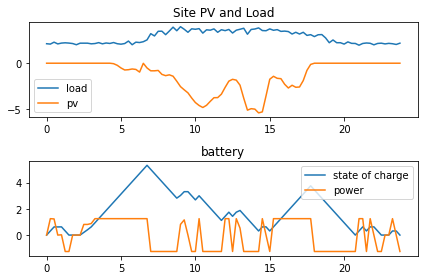

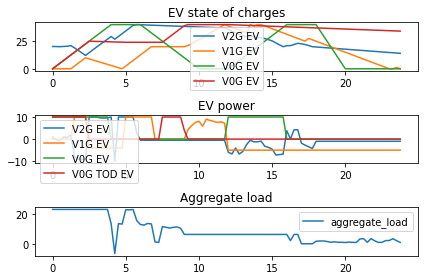

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

aggregate_load = site_dict['aggregate_load']    # the combined load on the grid from the site


battery_power = site_dict['battery']['delta']       # battery power
battery_soc = site_dict['battery']['SOC']           # battery state of charge

ev1_soc = site_dict['evs'][0]['SOC']
ev1_power = site_dict['evs'][0]['delta']

ev2_soc = site_dict['evs'][1]['SOC']
ev2_power = site_dict['evs'][1]['delta']

ev3_soc = site_dict['evs'][2]['SOC']
ev3_power = site_dict['evs'][2]['delta']

ev4_soc = site_dict['evs'][3]['SOC']
ev4_power = site_dict['evs'][3]['delta']



colors = sns.color_palette()
hrs = np.arange(0, len(load_profile)) / 4

plt.subplot(2,1,1)
plt.plot(hrs, load_profile, label='load')
plt.plot(hrs, pv_profile, label='pv')
plt.title('Site PV and Load')
plt.legend()

plt.subplot(2,1,2)
plt.plot(hrs, battery_soc, label='state of charge')
plt.plot(hrs, battery_power, label='power')
plt.title('battery')
plt.legend()

plt.tight_layout()
plt.show()

plt.subplot(3,1,1)
for i in range(4):
    plt.plot(hrs, site_dict['evs'][i]['SOC'], label=site_dict['evs'][i]['charge_mode'] + ' EV')
plt.title('EV state of charges')
plt.legend()

plt.subplot(3,1,2)
for i in range(4):
    if (site_dict['evs'][i]['charge_mode'] == 'V0G') and (retrieve_value(site_dict['evs'][i],'tod_charging') is not None):
        plt.plot(hrs, site_dict['evs'][i]['delta'], label=site_dict['evs'][i]['charge_mode'] + ' TOD EV')
    else:
        plt.plot(hrs, site_dict['evs'][i]['delta'], label=site_dict['evs'][i]['charge_mode'] + ' EV')
plt.title('EV power')
plt.legend()

plt.subplot(3,1,3)
plt.plot(hrs, aggregate_load, label='aggregate_load')
plt.legend()
plt.title('Aggregate load')

plt.tight_layout()
plt.show()